# House Prices：EDA + 回归机器学习完整实战

本 Notebook 按照 **ITMO AI Talent Hub 第一部分：EDA 和机器学习实战考核** 的思路设计。

目标不是 Kaggle 排名，而是训练一套可以迁移到陌生数据集的工作流：

**读取数据 → 数据理解 → 数据质量 → EDA → 异常值 → 相关性 → 特征处理 → Train/Validation Split → Pipeline → Baseline → 模型比较 → 指标 → 特征重要性 → 结论**

数据集：Kaggle **House Prices - Advanced Regression Techniques**。

建议第一次完整运行并阅读注释；第二次在空 Notebook 中重新实现；第三次严格计时 2 小时。

## 0. 考试目标

本案例重点覆盖：

- pandas：读取、筛选、排序、groupby、merge、缺失值、重复值、字符串操作
- 数据质量：missing、duplicates、异常值、潜在重复实体、逻辑一致性
- 统计：mean / median / quantile / variance、Pearson / Spearman
- 可视化：histogram、boxplot、scatter、heatmap
- 回归：Ridge + Random Forest
- 验证：train/validation split、Pipeline、防止 preprocessing leakage
- 指标：MAE、RMSE、R²、RMSLE
- 解释：Permutation Importance

**考试原则：你负责判断做什么、为什么做；AI 可以负责快速实现怎么做。**

In [2]:
# 如果缺少依赖，可运行：
# %pip install pandas numpy matplotlib seaborn scikit-learn

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


## 1. 定位数据文件

Kaggle 下载后通常至少包含：

- `train.csv`
- `test.csv`
- `data_description.txt`

把 `DATA_DIR` 改成你的数据目录。

In [5]:
# Windows 示例：
# DATA_DIR = Path(r"house-prices")

# Linux/macOS 示例：
# DATA_DIR = Path("/home/yourname/Downloads/house-prices")

DATA_DIR = Path(r"house-prices")

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
description_path = DATA_DIR / "data_description.txt"

print("当前目录:", DATA_DIR.resolve())
print("train.csv:", train_path.exists())
print("test.csv :", test_path.exists())
print("description:", description_path.exists())


当前目录: C:\Users\Tolia\Documents\GitHub\ITMO-PE\EnterExam\ai\Practice\S1-1\house-prices
train.csv: True
test.csv : True
description: True


In [6]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("train shape:", train.shape)
print("test shape :", test.shape)

display(train.head())
display(test.head())


train shape: (1460, 81)
test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## 2. 快速理解数据

拿到陌生数据集时，第一分钟应该回答：

1. 有多少行、多少列？
2. target 是什么？
3. 哪些变量是数值？
4. 哪些变量是类别？
5. 有没有明显缺失？
6. 有没有 ID 字段？

In [7]:
print("--- train.info() ---")
train.info()

print("\n--- 数值变量统计 ---")
display(train.describe().T)

print("\n--- 类别变量统计 ---")
display(train.describe(include=["object"]).T)


--- train.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0



--- 类别变量统计 ---


,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


In [8]:
TARGET = "SalePrice"
ID_COL = "Id"

print("Target:", TARGET)
print("Target dtype:", train[TARGET].dtype)
print("Target unique values:", train[TARGET].nunique())

# SalePrice 是连续数值，因此这是 regression。
# Id 是实体标识符，通常不作为普通预测特征。
X_raw = train.drop(columns=[TARGET, ID_COL])
y_raw = train[TARGET].copy()

print("X shape:", X_raw.shape)
print("y shape:", y_raw.shape)


Target: SalePrice
Target dtype: int64
Target unique values: 663
X shape: (1460, 79)
y shape: (1460,)


## 3. 缺失值分析

**注意：缺失值不一定代表错误。**

House Prices 中某些空值实际上可能意味着“没有该设施”，例如没有车库、地下室、泳池等。因此真正处理前应该阅读 `data_description.txt`。

In [24]:
missing_count = train.isna().sum().sort_values(ascending=False)
missing_rate = train.isna().mean().sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_rate": missing_rate
})

display(missing_report.head(30))

print("缺失比例最高 Top 3：")
display(missing_rate[missing_rate > 0].head(3))


,missing_count,missing_rate
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageQual,81,0.055479
GarageFinish,81,0.055479
GarageType,81,0.055479


缺失比例最高 Top 3：


PoolQC         0.995205
MiscFeature    0.963014
Alley          0.937671
dtype: float64

In [ ]:
if description_path.exists():
    text = description_path.read_text(encoding="utf-8", errors="ignore")
    print(text[:12000])
else:
    print("没有找到 data_description.txt，请确认 DATA_DIR。")


## 4. 重复记录与重复实体

考试中不要只检查整行重复，还应该检查 ID 是否重复。

如果 ID 不可靠，可以尝试用多个相对稳定的字段构造 fingerprint，寻找潜在重复实体。

In [10]:
print("完全重复行数:", train.duplicated().sum())

print("重复 Id 数量:", train[ID_COL].duplicated().sum())
print("唯一 Id 数量:", train[ID_COL].nunique())
print("总行数:", len(train))

dup_ids = train.loc[train[ID_COL].duplicated(keep=False), ID_COL]
display(train[train[ID_COL].isin(dup_ids)].sort_values(ID_COL).head(20))


完全重复行数: 0
重复 Id 数量: 0
唯一 Id 数量: 1460
总行数: 1460


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [11]:
# 通用“部分 ID 缺失时寻找潜在重复实体”的方法。
candidate_keys = [
    c for c in ["Neighborhood", "GrLivArea", "YearBuilt", "GarageCars"]
    if c in train.columns
]

if candidate_keys:
    potential_dup = train.duplicated(subset=candidate_keys, keep=False)
    print("按", candidate_keys, "组合后可能重复的行数:", potential_dup.sum())
    display(
        train.loc[
            potential_dup,
            candidate_keys + [TARGET]
        ].sort_values(candidate_keys).head(20)
    )


按 ['Neighborhood', 'GrLivArea', 'YearBuilt', 'GarageCars'] 组合后可能重复的行数: 86


,Neighborhood,GrLivArea,YearBuilt,GarageCars,SalePrice
1004,Blmngtn,1504,2005,2,181000
1023,Blmngtn,1504,2005,2,191000
235,BrDale,987,1971,1,89500
430,BrDale,987,1971,1,85400
232,BrDale,987,1972,1,94500
363,BrDale,987,1972,1,118000
837,BrDale,987,1973,1,100000
1378,BrDale,987,1973,1,83000
593,CollgCr,848,2003,2,140000
850,CollgCr,848,2003,2,131500


## 5. 基础统计

平均数容易受到极端值影响；median 通常更稳健。quantile 可以快速描述尾部。

In [12]:
target_stats = pd.Series({
    "mean": y_raw.mean(),
    "median": y_raw.median(),
    "std": y_raw.std(),
    "variance": y_raw.var(),
    "q01": y_raw.quantile(0.01),
    "q25": y_raw.quantile(0.25),
    "q50": y_raw.quantile(0.50),
    "q75": y_raw.quantile(0.75),
    "q99": y_raw.quantile(0.99),
})

display(target_stats)
print("mean / median =", y_raw.mean() / y_raw.median())


mean        1.809212e+05
median      1.630000e+05
std         7.944250e+04
variance    6.311111e+09
q01         6.181597e+04
q25         1.299750e+05
q50         1.630000e+05
q75         2.140000e+05
q99         4.425670e+05
dtype: float64

mean / median = 1.109945987057736


## 6. Target EDA：SalePrice

如果 target 明显右偏，可以考虑 `log1p(target)`。

`log1p(x)` 等于 `log(1+x)`，相比直接 `log(x)` 对 0 更安全。

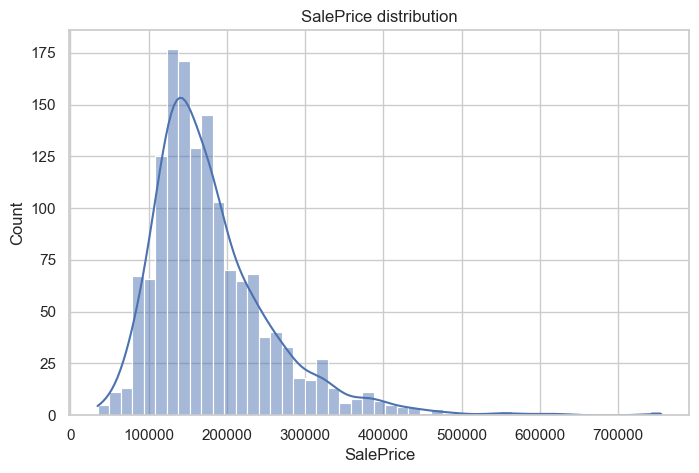

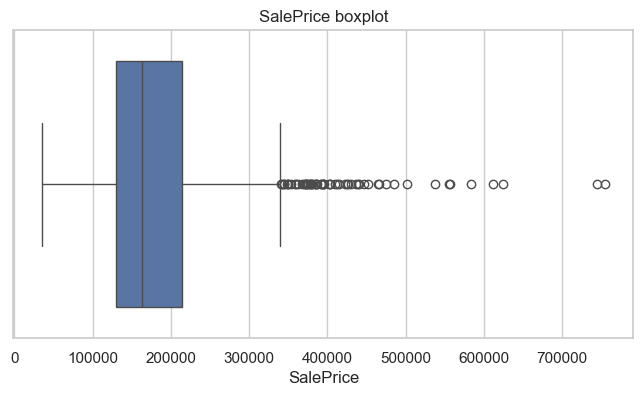

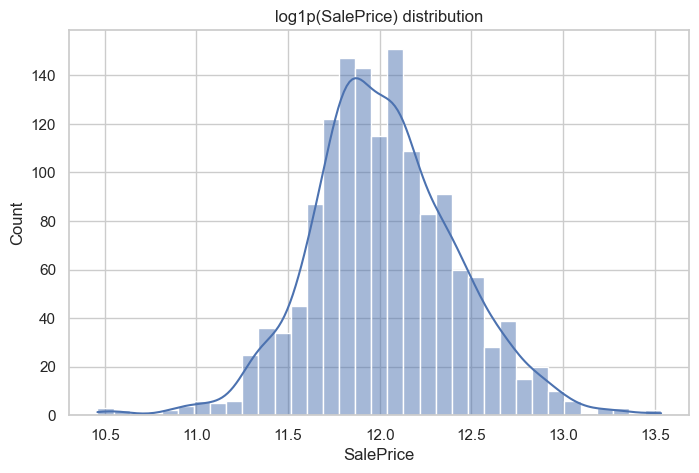

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(y_raw, kde=True, ax=ax)
ax.set_title("SalePrice distribution")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=y_raw, ax=ax)
ax.set_title("SalePrice boxplot")
plt.show()

y_log = np.log1p(y_raw)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(y_log, kde=True, ax=ax)
ax.set_title("log1p(SalePrice) distribution")
plt.show()


## 7. 数值 / 类别变量识别

In [14]:
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
numeric_feature_cols = [
    c for c in numeric_cols
    if c not in [TARGET, ID_COL]
]

categorical_cols = train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Numeric feature count:", len(numeric_feature_cols))
print("Categorical feature count:", len(categorical_cols))
print("Numeric examples:", numeric_feature_cols[:20])
print("Categorical examples:", categorical_cols[:20])


Numeric feature count: 36
Categorical feature count: 43
Numeric examples: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath']
Categorical examples: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond']


## 8. 单变量 EDA

考试中不要把全部变量都画一遍。优先看有业务意义、缺失较多、与 target 可能关系明显的变量。

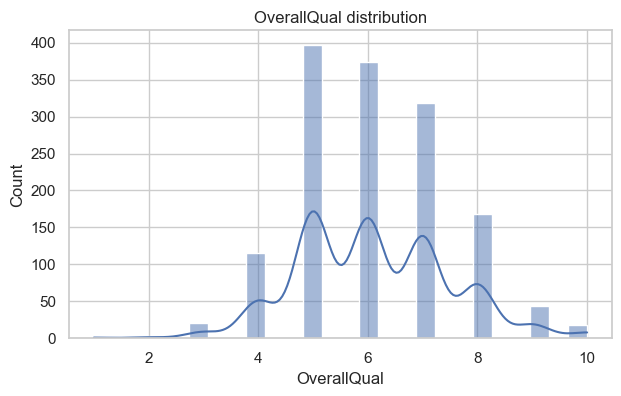

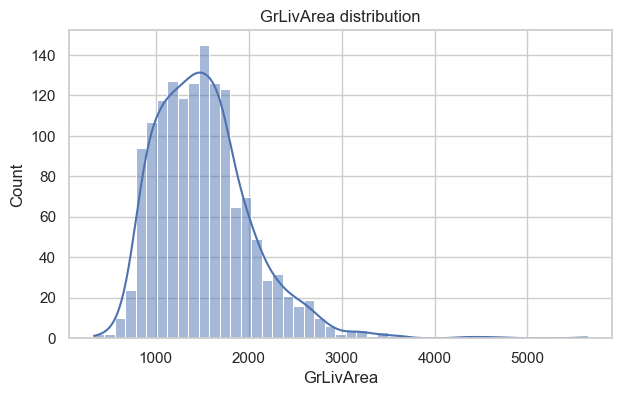

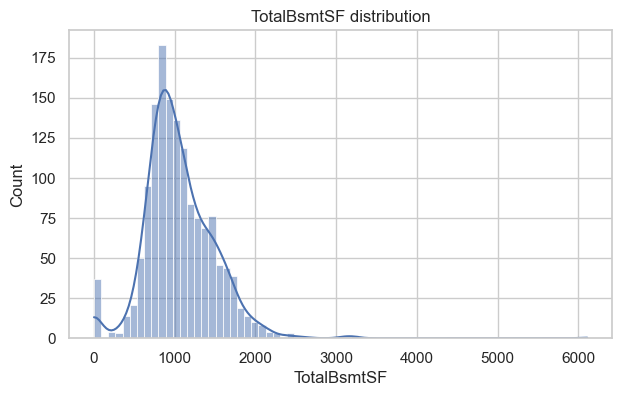

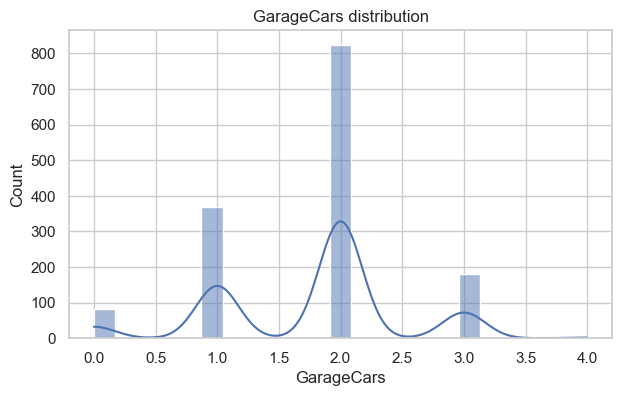

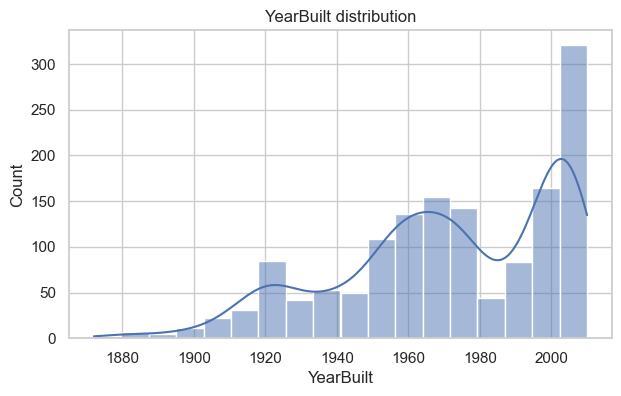

In [15]:
plot_cols = [
    c for c in [
        "OverallQual",
        "GrLivArea",
        "TotalBsmtSF",
        "GarageCars",
        "YearBuilt"
    ]
    if c in train.columns
]

for col in plot_cols:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.histplot(train[col], kde=True, ax=ax)
    ax.set_title(f"{col} distribution")
    plt.show()


## 9. 双变量 EDA

数值变量常用 scatter；类别变量常用 boxplot。

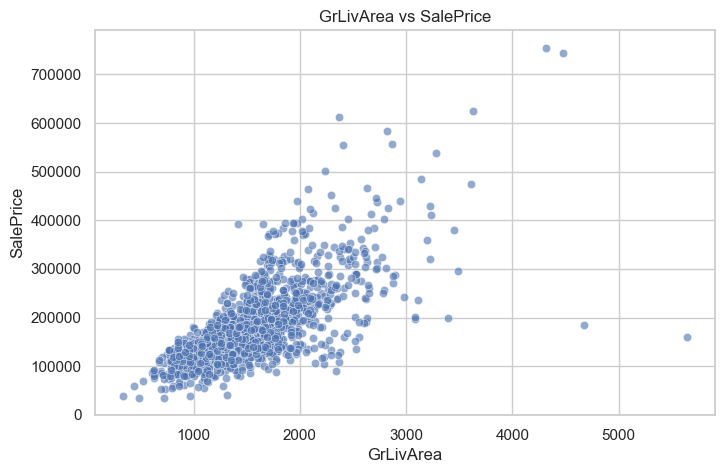

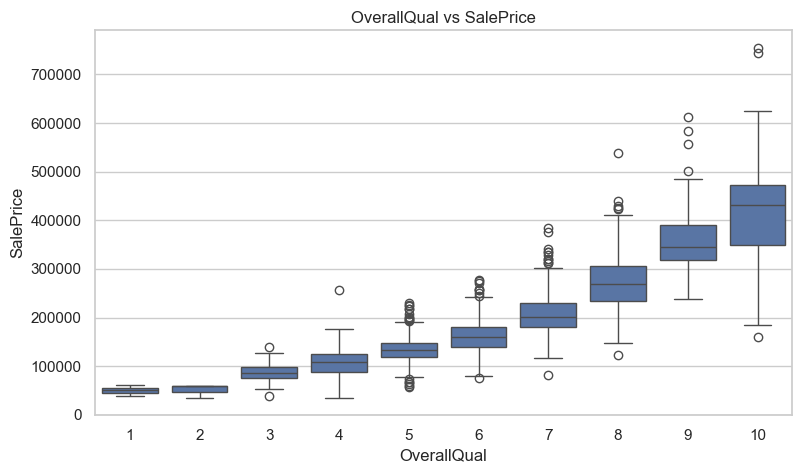

In [16]:
if "GrLivArea" in train.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(
        data=train,
        x="GrLivArea",
        y=TARGET,
        alpha=0.6,
        ax=ax
    )
    ax.set_title("GrLivArea vs SalePrice")
    plt.show()

if "OverallQual" in train.columns:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(
        data=train,
        x="OverallQual",
        y=TARGET,
        ax=ax
    )
    ax.set_title("OverallQual vs SalePrice")
    plt.show()


## 10. GroupBy：从数据得到可解释结论

例如比较不同 Neighborhood 的平均价格和中位数。注意小样本组可能导致不稳定结论。

In [17]:
if "Neighborhood" in train.columns:
    neighborhood_stats = (
        train.groupby("Neighborhood")[TARGET]
        .agg(["count", "mean", "median"])
        .sort_values("median", ascending=False)
    )

    display(neighborhood_stats.head(15))

    stable_groups = neighborhood_stats[
        neighborhood_stats["count"] >= 10
    ]

    print("样本数 >= 10 的组：")
    display(stable_groups.head(10))


,count,mean,median
Neighborhood,,,
NridgHt,77,316270.623377,315000.0
NoRidge,41,335295.317073,301500.0
StoneBr,25,310499.000000,278000.0
Timber,38,242247.447368,228475.0
Somerst,86,225379.837209,225500.0
Veenker,11,238772.727273,218000.0
Crawfor,51,210624.725490,200624.0
ClearCr,28,212565.428571,200250.0
CollgCr,150,197965.773333,197200.0


样本数 >= 10 的组：


,count,mean,median
Neighborhood,,,
NridgHt,77,316270.623377,315000.0
NoRidge,41,335295.317073,301500.0
StoneBr,25,310499.000000,278000.0
Timber,38,242247.447368,228475.0
Somerst,86,225379.837209,225500.0
Veenker,11,238772.727273,218000.0
Crawfor,51,210624.725490,200624.0
ClearCr,28,212565.428571,200250.0
CollgCr,150,197965.773333,197200.0


## 11. Pearson / Spearman

Pearson 主要衡量线性相关；Spearman 对数据排序后计算相关性，主要反映单调关系。

**相关性 ≠ 因果关系。**

In [18]:
pearson_corr = (
    train[numeric_feature_cols + [TARGET]]
    .corr(method="pearson")[TARGET]
    .sort_values(ascending=False)
)

spearman_corr = (
    train[numeric_feature_cols + [TARGET]]
    .corr(method="spearman")[TARGET]
    .sort_values(ascending=False)
)

corr_compare = pd.DataFrame({
    "pearson": pearson_corr,
    "spearman": spearman_corr
})

corr_compare["abs_diff"] = (
    corr_compare["pearson"] - corr_compare["spearman"]
).abs()

display(corr_compare.head(15))


,pearson,spearman,abs_diff
1stFlrSF,0.605852,0.575408,0.030444
2ndFlrSF,0.319334,0.293598,0.025736
3SsnPorch,0.044584,0.065440,0.020857
BedroomAbvGr,0.168213,0.234907,0.066694
BsmtFinSF1,0.386420,0.301871,0.084549
BsmtFinSF2,-0.011378,-0.038806,0.027428
BsmtFullBath,0.227122,0.225125,0.001997
BsmtHalfBath,-0.016844,-0.012189,0.004655
BsmtUnfSF,0.214479,0.185197,0.029282
EnclosedPorch,-0.128578,-0.218394,0.089816


In [ ]:
top_corr_features = (
    train[numeric_feature_cols + [TARGET]]
    .corr(method="pearson")[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .head(12)
    .index
    .tolist()
)

print("Top correlated numerical features:")
print(top_corr_features)

corr_matrix = train[top_corr_features + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlation heatmap")
plt.show()


## 12. 异常值检查

不要看到异常值就自动删除。

正确流程：

**发现 → 调查 → 判断 → 处理 → 记录理由**

IQR 方法可以用于“候选异常值”检测，但统计异常不等于错误数据。

In [ ]:
def iqr_outlier_mask(series, multiplier=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    mask = (series < lower) | (series > upper)
    return mask, lower, upper


if "GrLivArea" in train.columns:
    print(
        train["GrLivArea"].quantile(
            [0.01, 0.05, 0.5, 0.95, 0.99, 0.995, 1.0]
        )
    )

    display(
        train.nlargest(
            10, "GrLivArea"
        )[[ID_COL, "GrLivArea", TARGET]]
    )

    mask, lower, upper = iqr_outlier_mask(train["GrLivArea"])

    print("IQR lower:", lower)
    print("IQR upper:", upper)
    print("Potential outliers:", mask.sum())


## 13. 逻辑一致性检查

真实考试可能故意加入字段之间互相矛盾的数据。这里练习基本规则检查。

In [ ]:
if {"YearBuilt", "YearRemodAdd"}.issubset(train.columns):
    inconsistent_years = train[
        train["YearRemodAdd"] < train["YearBuilt"]
    ]

    print(
        "YearRemodAdd < YearBuilt 的记录数:",
        len(inconsistent_years)
    )

    display(
        inconsistent_years[
            [ID_COL, "YearBuilt", "YearRemodAdd"]
        ].head()
    )

if {"GarageCars", "GarageArea"}.issubset(train.columns):
    inconsistent_garage = (
        (train["GarageCars"] == 0)
        & (train["GarageArea"] > 0)
    )

    print(
        "GarageCars=0 但 GarageArea>0:",
        inconsistent_garage.sum()
    )


## 14. 字符串操作模板

House Prices 的类别数据比较干净，但考试要求你会处理文本列。以下是通用操作。

In [ ]:
if categorical_cols:
    sample_cat = categorical_cols[0]
    s = train[sample_cat].astype("string")

    print("示例列:", sample_cat)
    print("strip + lower:")
    display(s.str.strip().str.lower().value_counts().head())

    # 常用操作：
    # s.str.strip()
    # s.str.lower()
    # s.str.contains("abc", na=False)
    # s.str.replace("old", "new", regex=False)


## 15. Merge / Join 模板

本数据集不需要 join，但考试要求熟悉这种操作。

In [ ]:
# 假设有一个额外表 extra_df：
#
# extra_df = pd.DataFrame({
#     "Id": [1, 2],
#     "external_score": [10, 20]
# })
#
# left_join = train.merge(extra_df, on="Id", how="left")
# inner_join = train.merge(extra_df, on="Id", how="inner")
# outer_join = train.merge(extra_df, on="Id", how="outer")
#
# left：保留左表全部记录
# inner：只保留两边都匹配的 key
# outer：保留两边所有 key

print("Merge 模板已写在注释中。")


# 16. Train / Validation Split

**重要：先 split，再 fit preprocessing。**

如果先用全部数据计算 imputer 的中位数、scaler 参数、类别集合等，validation 信息就可能泄漏到训练过程。

`Pipeline + ColumnTransformer` 是解决这一问题的标准工程方式。

In [ ]:
X = train.drop(columns=[TARGET, ID_COL]).copy()
y = train[TARGET].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)


In [ ]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))


## 17. Preprocessing Pipeline

数值列：

`median imputation → StandardScaler`

类别列：

`most-frequent imputation → OneHotEncoder`

`handle_unknown="ignore"` 很重要：如果 validation/test 出现训练数据没出现过的类别，不会因为 one-hot 编码维度不同而直接报错。

注意：树模型不需要标准化，所以后面会建立一个 tree-specific preprocessing。

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)


# 18. Baseline 1：Ridge Regression

Ridge 是一个非常适合当前训练的线性 baseline。

它可以作为“简单模型”，同时比裸 Linear Regression 更适合大量 one-hot 特征和一定程度的多重共线性。

In [ ]:
ridge_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=10.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_valid)


## 19. 回归指标

- **MAE**：平均绝对误差，单位与价格相同，容易解释。
- **RMSE**：对大误差惩罚更强。
- **R²**：相对于简单均值预测 baseline 的解释程度。
- **RMSLE**：在 log 空间衡量误差，对价格这种跨度大的变量比较有意义。

House Prices 官方评价思路采用 log-space RMSE，因此本案例特别值得练习 RMSLE。

In [ ]:
def regression_metrics(y_true, y_pred):
    # RMSLE 要求预测值非负；如果模型产生负预测，先截断到 0。
    y_pred_nonnegative = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    rmsle = np.sqrt(
        mean_squared_error(
            np.log1p(y_true),
            np.log1p(y_pred_nonnegative)
        )
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "RMSLE": rmsle
    }


ridge_metrics = regression_metrics(y_valid, ridge_pred)
display(pd.Series(ridge_metrics, name="Ridge"))


# 20. Baseline 2：Random Forest

Random Forest 可以捕捉非线性关系和特征交互。

考试中不需要进行大规模 hyperparameter tuning。先得到一个合理 baseline，再判断是否值得继续优化。

In [ ]:
# 树模型不依赖 StandardScaler。
numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer_tree, categorical_features)
    ]
)

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor_tree),
    ("model", RandomForestRegressor(
        n_estimators=400,
        max_features="sqrt",
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_valid)

rf_metrics = regression_metrics(y_valid, rf_pred)
display(pd.Series(rf_metrics, name="RandomForest"))


In [ ]:
results = pd.DataFrame(
    [ridge_metrics, rf_metrics],
    index=["Ridge", "RandomForest"]
)

display(results.sort_values("RMSE"))


# 21. Log-target Regression

`SalePrice` 右偏，因此可以尝试：

`y_log = log1p(y)`

训练完成后：

`price = expm1(pred_log)`

这里不要把 log transformation 当作“永远正确”的规则；应该根据 target 分布、模型假设和评价指标决定。

In [ ]:
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

ridge_log_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=10.0))
])

ridge_log_model.fit(X_train, y_train_log)
ridge_log_pred = ridge_log_model.predict(X_valid)

# 从 log(price) 恢复到原始价格。
ridge_log_pred_price = np.expm1(ridge_log_pred)

ridge_log_metrics = regression_metrics(
    y_valid,
    ridge_log_pred_price
)

display(pd.Series(
    ridge_log_metrics,
    name="Ridge + log target"
))


In [ ]:
log_rmse = np.sqrt(
    mean_squared_error(
        y_valid_log,
        ridge_log_pred
    )
)

print("Log-space RMSE:", log_rmse)
print(
    "RMSLE after inverse transform:",
    ridge_log_metrics["RMSLE"]
)


# 22. Actual vs Predicted

这是一个快速 sanity check。

如果预测值与真实值完全没有关系，那么模型指标再漂亮也应该进一步调查。

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

sns.scatterplot(
    x=y_valid,
    y=rf_pred,
    alpha=0.6,
    ax=ax
)

min_value = min(y_valid.min(), rf_pred.min())
max_value = max(y_valid.max(), rf_pred.max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

ax.set_xlabel("Actual SalePrice")
ax.set_ylabel("Predicted SalePrice")
ax.set_title("Actual vs Predicted")

plt.show()


# 23. Residual Analysis

残差：

`residual = actual - predicted`

如果残差随着预测值出现明显结构，说明模型可能存在系统性误差。

In [ ]:
residuals = y_valid - rf_pred

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    x=rf_pred,
    y=residuals,
    alpha=0.6,
    ax=ax
)

ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted SalePrice")
ax.set_ylabel("Residual = Actual - Predicted")
ax.set_title("Residuals vs Predictions")

plt.show()

display(pd.Series(residuals).describe())


# 24. Permutation Importance

Permutation importance 的思想：

> 把一个 feature 随机打乱，如果模型性能明显下降，那么该 feature 对当前模型预测比较重要。

注意：

**Feature importance ≠ causality。**

例如 `OverallQual` 很重要，并不意味着“人为提高这个变量 1 分就必然造成房价增加某个固定金额”。

In [ ]:
perm = permutation_importance(
    rf_model,
    X_valid,
    y_valid,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

display(perm_df.head(20))


In [ ]:
top_perm = perm_df.head(15).sort_values(
    "importance_mean"
)

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    top_perm["feature"],
    top_perm["importance_mean"],
    xerr=top_perm["importance_std"]
)

ax.set_xlabel(
    "Decrease in score when feature is permuted"
)
ax.set_title("Top permutation importances")

plt.show()


# 25. 过拟合检查

比较 train 和 validation 指标。

如果训练集非常好、validation 明显差，可能存在过拟合。

In [ ]:
rf_train_pred = rf_model.predict(X_train)

rf_train_metrics = regression_metrics(
    y_train,
    rf_train_pred
)

rf_valid_metrics = regression_metrics(
    y_valid,
    rf_pred
)

overfit_check = pd.DataFrame(
    [rf_train_metrics, rf_valid_metrics],
    index=["train", "validation"]
)

display(overfit_check)


# 26. 可选：K-Fold Cross Validation

正式考试时间紧时不一定需要做。

但应该知道：

- train/validation split：快速估计泛化能力
- K-fold：将训练数据分成多个 fold，重复训练/验证，得到更稳定的估计

如果使用 Pipeline，CV 中每个 fold 的 preprocessing 也会在对应训练 fold 上 fit，从而避免 leakage。

In [ ]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("CV RMSE:", -cv_scores)
print("Mean CV RMSE:", -cv_scores.mean())
print("Std CV RMSE:", cv_scores.std())


# 27. 精确过滤条件练习

考试指南特别强调：自动检查中很多错误来自**条件写错**，而不是算法问题。

牢记 pandas 多条件筛选需要使用 `&` / `|`，并给每个条件加括号。

In [ ]:
if {"GrLivArea", "OverallQual"}.issubset(train.columns):
    filtered = train[
        train["GrLivArea"].between(
            1500, 2500, inclusive="both"
        )
        & (train["OverallQual"] >= 7)
    ]

    print("filtered rows:", len(filtered))

    display(
        filtered[
            [ID_COL, "GrLivArea", "OverallQual", TARGET]
        ].head()
    )

# 常见条件：
# train[train["GarageArea"].notna()]      # 非空
# train[train["GarageArea"].isna()]       # 空值
# train[(train["OverallQual"] >= 8) | (train["GrLivArea"] > 2500)]


# 28. 可选：Kaggle test 预测

注意：

**validation 用来评估模型；test.csv 是最终无标签数据。**

只有完成模型选择以后，才应该用全部训练数据重新 fit，然后预测 test。

In [ ]:
final_model = rf_model

# 最终模型使用全部带标签训练数据 fit。
final_model.fit(X, y)

X_test = test.drop(
    columns=[ID_COL],
    errors="ignore"
)

test_pred = final_model.predict(X_test)
test_pred = np.maximum(test_pred, 0)

submission = pd.DataFrame({
    "Id": test[ID_COL],
    "SalePrice": test_pred
})

display(submission.head())
print("submission shape:", submission.shape)


In [ ]:
submission_path = DATA_DIR / "submission_baseline.csv"

submission.to_csv(
    submission_path,
    index=False
)

print("saved:", submission_path.resolve())


# 29. 最终考试检查清单

### 数据理解
- [ ] 我知道数据有多少行、多少列。
- [ ] 我明确了 target。
- [ ] 我区分了 numerical / categorical。
- [ ] 我没有把 ID 或 target 放进 feature。

### 数据质量
- [ ] Missing values
- [ ] Duplicate rows
- [ ] Duplicate entities / ID
- [ ] Outliers
- [ ] 至少一个逻辑一致性检查
- [ ] 理解关键 missing value 的业务含义

### EDA
- [ ] Target distribution
- [ ] log target
- [ ] Histogram
- [ ] Boxplot
- [ ] Scatter
- [ ] GroupBy
- [ ] Pearson
- [ ] Spearman
- [ ] 每个重要结论有图或数字支持

### ML
- [ ] 判断为 regression
- [ ] Train/validation split
- [ ] Pipeline
- [ ] 没有 preprocessing leakage
- [ ] Ridge baseline
- [ ] Random Forest
- [ ] MAE
- [ ] RMSE
- [ ] R²
- [ ] RMSLE / log-space RMSE
- [ ] Actual vs Predicted
- [ ] Residual analysis
- [ ] Feature importance

### 最终表达
- [ ] 能解释为什么选这个模型
- [ ] 能解释为什么选这个 metric
- [ ] 能指出重要特征
- [ ] 能区分 correlation / importance 与 causality
- [ ] 能指出模型局限
- [ ] 最后保留 10–15 分钟检查条件、格式和结果


# 30. AI 使用策略

## 应由你独立判断

1. 任务类型是什么？
2. target 是什么？
3. 哪些字段是 ID？
4. 缺失值代表什么？
5. 哪些异常值值得调查？
6. 模型为什么选择 regression / Ridge / Random Forest？
7. metric 为什么这样选？
8. EDA 结果意味着什么？
9. 有没有 leakage？
10. 最终结论是否合理？

## 可以交给 AI

- pandas 查询语句
- groupby / merge / filtering
- visualization 代码
- ColumnTransformer / Pipeline boilerplate
- sklearn 模型初始化
- metric 计算
- debugging
- 代码重构
- 检查潜在 leakage
- 帮助解释你已经得到的结果

**核心原则：AI 可以帮助你快速写代码，但你必须能够解释代码和结果。**

考试中还应记录 AI 的贡献，例如：

> “AI helped generate the preprocessing Pipeline and debug the OneHotEncoder configuration. I independently selected the target, identified the regression task, checked missing values, selected metrics, interpreted EDA and validated the final results.”


# 31. 2 小时模拟考试时间表

| 时间 | 工作 |
|---|---|
| 00:00–00:10 | 数据加载 + 数据理解 |
| 00:10–00:25 | Missing + duplicates + invalid values |
| 00:25–00:40 | Target EDA + outliers |
| 00:40–00:55 | Feature EDA + correlation |
| 00:55–01:10 | Cleaning + preprocessing |
| 01:10–01:30 | Baseline models |
| 01:30–01:40 | Metrics |
| 01:40–01:50 | Feature importance + residuals |
| 01:50–02:00 | Final check + conclusion |

第一次可以超时。第二次开始要求自己控制在 2 小时以内。

最终要形成可迁移的肌肉记忆：

`shape → info → describe → missing → duplicates → target → distribution → correlation → outliers → split → pipeline → baseline → metrics → interpretation → conclusion`
